In [ ]:
# Importing Data Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Opening the dataset
url = r"/home/youssef/Desktop/Data_Projects/Egypt_Education/Data/education_cleaned.csv"
df = pd.read_csv(url)
df.head()

,Student_Name,Student_Age,Student_Year,Father_Degree,Mother_Degree,Education_Type,Subject_1,Subject_2,Subject_3,Subject_4,Subject_5,Subject_6,Subject_7,Subject_8,Subject_9,Subject_10,Total_Score,Average_Score,Performance,Student_Year_num
0,Allison Lang,18,9,High School,High School,IB,72.236740,85.931149,65.698513,84.163844,78.179414,50.578209,70.071681,80.294509,72.709741,59.080678,718.944478,71.894448,Good,9
1,Jaclyn Mcneil,14,9,Bachelor,PhD,IB,91.603078,73.186427,64.240239,47.786542,83.138581,66.913702,42.587211,87.997009,89.176862,78.493158,725.122809,72.512281,Good,9
2,Melissa Lee,16,10,Unknown,PhD,IB,100.000000,83.985923,89.378162,82.446853,86.368818,90.347020,100.000000,83.972296,69.212961,79.206634,864.918668,86.491867,Excellent,10
3,Timothy Maxwell,14,10,Bachelor,Bachelor,Thanweya,91.082131,100.000000,78.802220,78.447670,64.606239,82.045421,69.869099,91.122870,95.207752,52.602706,803.786108,80.378611,Good,10
4,Eric Steele,17,11,PhD,Unknown,IGCSE,74.906144,69.518146,65.284841,56.317028,69.758140,85.810641,63.776955,61.802599,84.951132,68.146467,700.272092,70.027209,Good,11


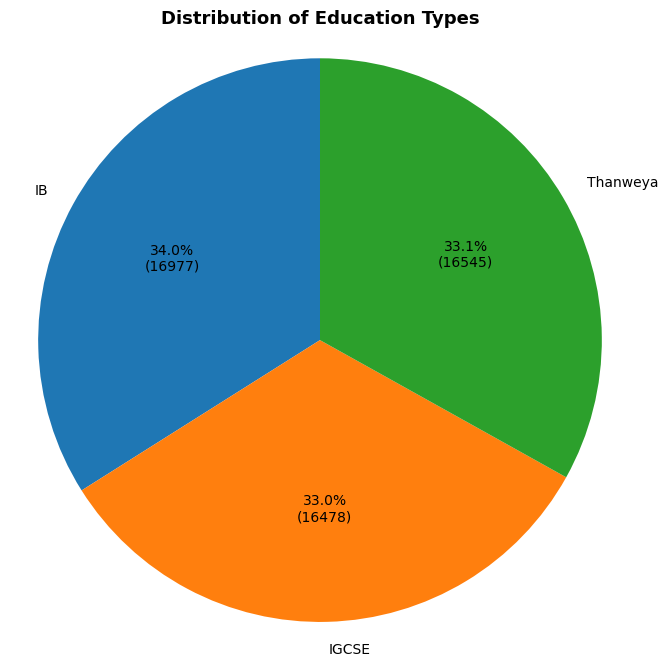

In [4]:
# Count values
counts = df["Education_Type"].value_counts().sort_index()
plt.figure(figsize=(8,8))

# Function to display both percentage and absolute values in the pie chart
def func(pct, allvals):
    absolute = int(pct/100. * sum(allvals))
    return f"{pct:.1f}%\n({absolute})"

# Plotting the pie chart
plt.pie(
    counts,
    labels=counts.index,
    autopct=lambda pct: func(pct, counts),
    startangle=90,
    textprops={'fontsize': 10}
)

# Adding title
plt.title("Distribution of Education Types", fontsize=13, fontweight='bold')
plt.axis('equal')
plt.show()

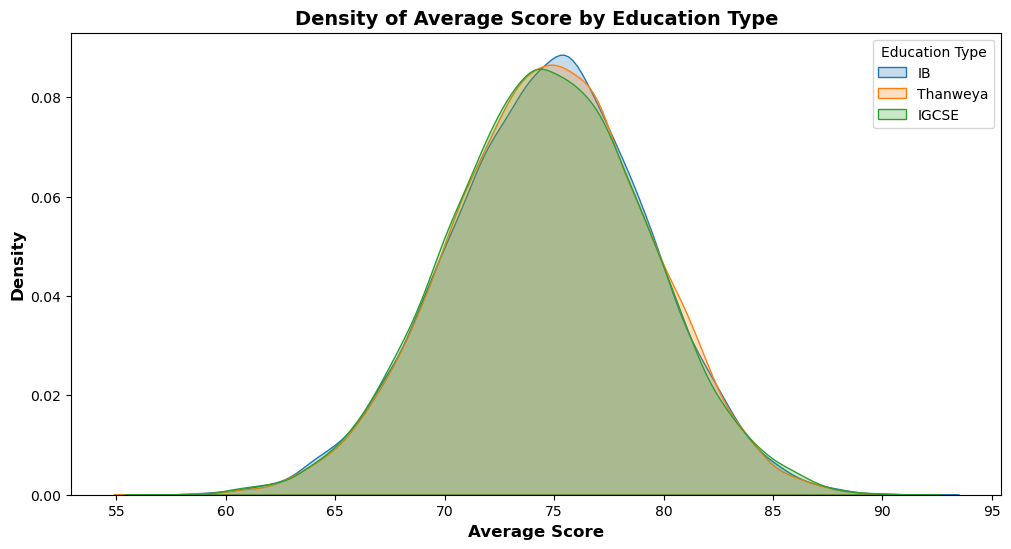

In [13]:
# Density plot: Average Score by Education Type
plt.figure(figsize=(12,6))
for etype in df["Education_Type"].unique():
    sns.kdeplot(df[df["Education_Type"]==etype]["Average_Score"], label=etype, fill=True)
plt.title("Density of Average Score by Education Type", fontsize=14, fontweight='bold')
plt.xlabel("Average Score", fontsize=12, fontweight='bold')
plt.ylabel("Density", fontsize=12, fontweight='bold')
plt.legend(title="Education Type")
plt.show()

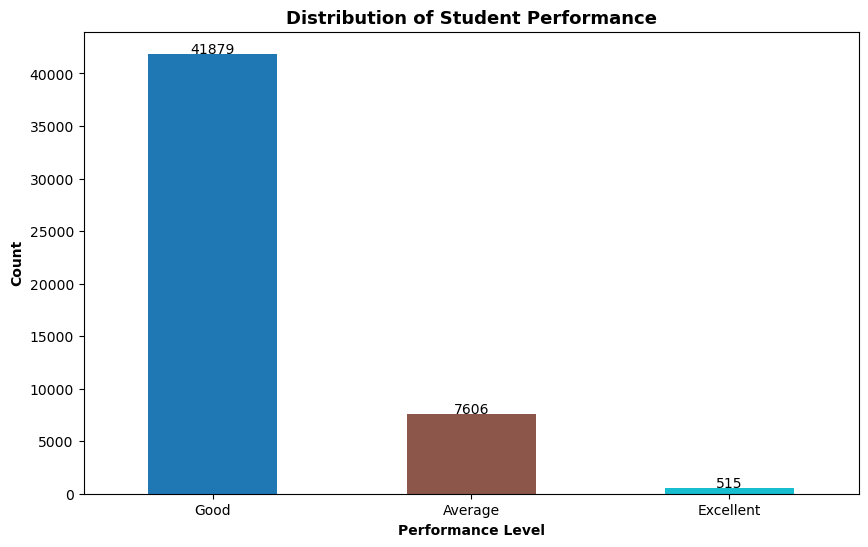

In [25]:
# Plotting the distribution of Performance levels
counts = df["Performance"].value_counts()

# Plotting the distribution of Performance levels
plt.figure(figsize=(10,6))
counts.plot(kind="bar", color=[plt.cm.tab10(i / (len(counts)-1) if len(counts)>1 else 0) for i in range(len(counts))])

# Adding titles and labels
plt.title("Distribution of Student Performance", fontsize=13, fontweight='bold')
plt.xlabel("Performance Level", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')

# Customizing ticks
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

# Adding value labels on top of bars
for i, v in enumerate(counts):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.show()

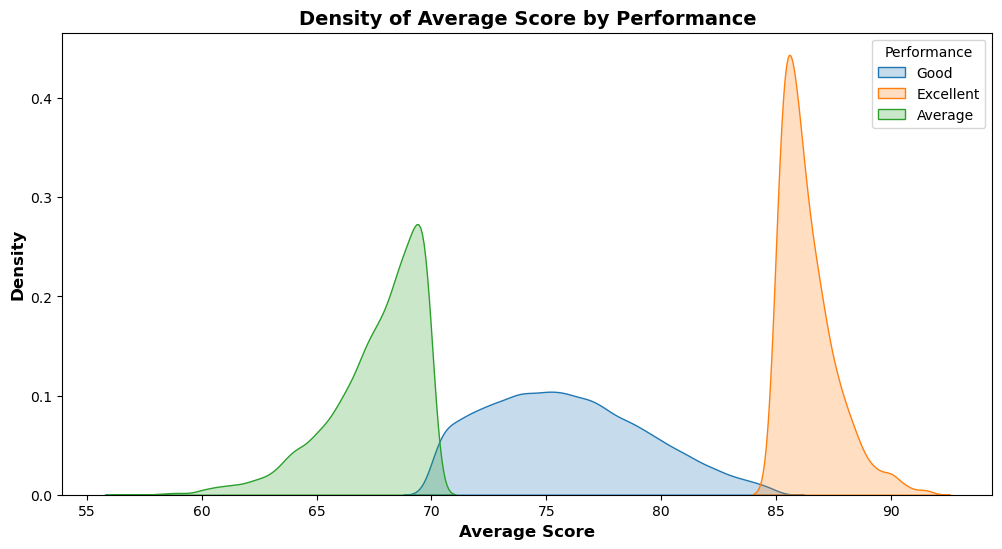

In [6]:
# Density plot: Average Score by Performance
plt.figure(figsize=(12,6))
for etype in df["Performance"].unique():
    sns.kdeplot(df[df["Performance"]==etype]["Average_Score"], label=etype, fill=True)
plt.title("Density of Average Score by Performance", fontsize=14, fontweight='bold')
plt.xlabel("Average Score", fontsize=12, fontweight='bold')
plt.ylabel("Density", fontsize=12, fontweight='bold')
plt.legend(title="Performance")
plt.show()

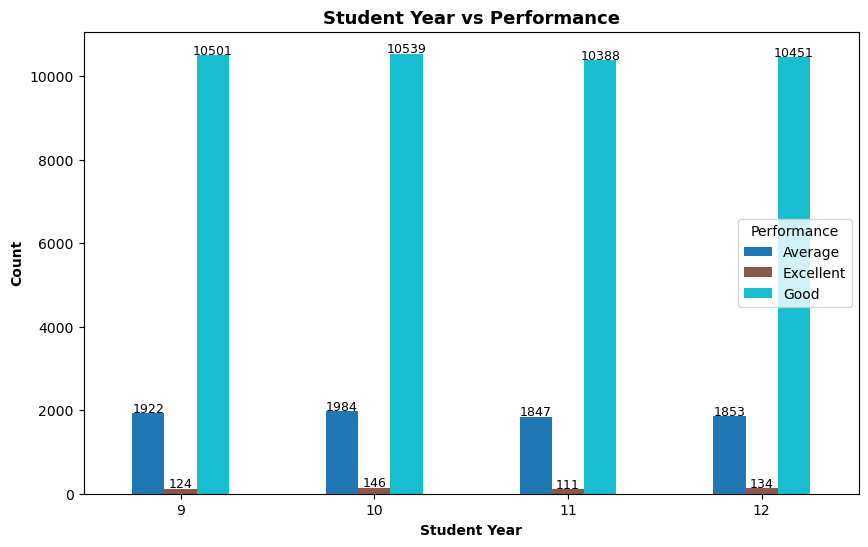

In [39]:
# Student Year vs Performance
counts = df.groupby(["Student_Year", "Performance"]).size().unstack(fill_value=0)

counts.plot(kind="bar", figsize=(10,6),
            color=[plt.cm.tab10(i / (len(counts.columns)-1)) for i in range(len(counts.columns))])

plt.title("Student Year vs Performance", fontsize=13, fontweight='bold')
plt.xlabel("Student Year", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

for container in plt.gca().containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x() + bar.get_width()/2, h + 20, int(h),
                     ha='center', fontsize=9)

plt.show()

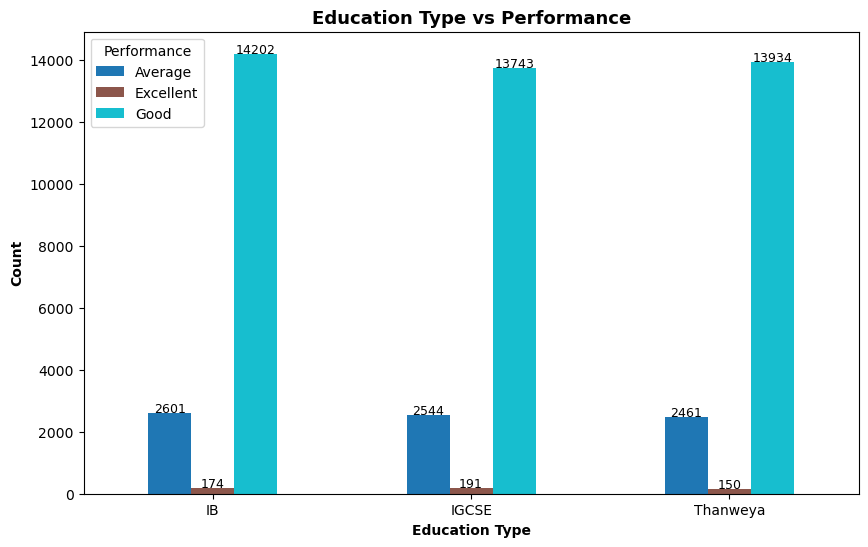

In [40]:
# Education Type vs Performance
counts = df.groupby(["Education_Type", "Performance"]).size().unstack(fill_value=0)

counts.plot(kind="bar", figsize=(10,6),
            color=[plt.cm.tab10(i / (len(counts.columns)-1)) for i in range(len(counts.columns))])

plt.title("Education Type vs Performance", fontsize=13, fontweight='bold')
plt.xlabel("Education Type", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

for container in plt.gca().containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x() + bar.get_width()/2, h + 20, int(h),
                     ha='center', fontsize=9)

plt.show()

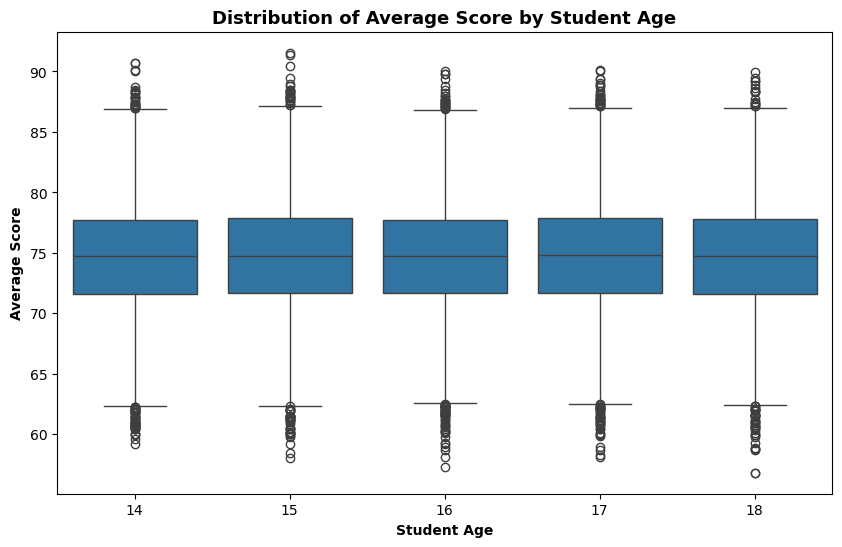

In [ ]:
# Box plot: Student Age vs Average Score
plt.figure(figsize=(10,6))
sns.boxplot(x="Student_Age", y="Average_Score", data=df, palette="Set2")
plt.title("Distribution of Average Score by Student Age", fontsize=13, fontweight='bold')
plt.xlabel("Student Age", fontsize=10, fontweight='bold')
plt.ylabel("Average Score", fontsize=10, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

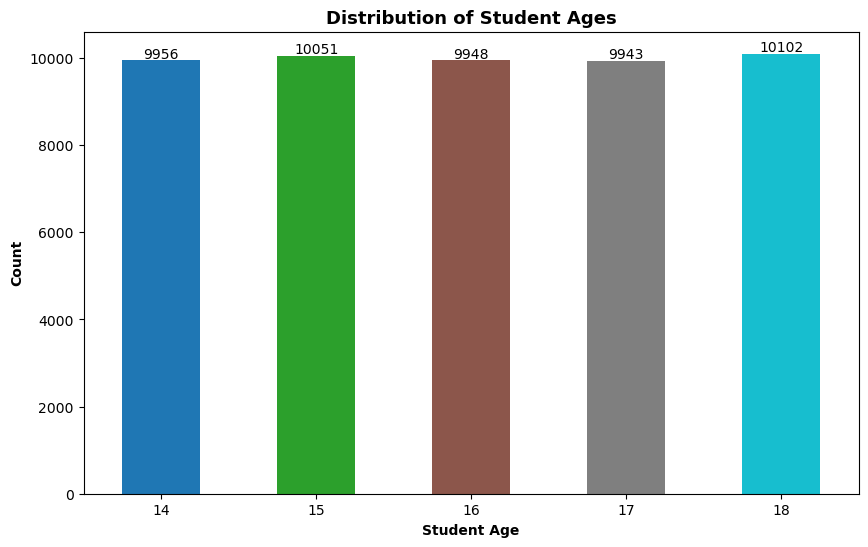

In [26]:
# Plotting the distribution of Student Ages
counts = df["Student_Age"].value_counts().sort_index()
counts.plot(kind="bar", figsize=(10,6), color=[plt.cm.tab10(i / (len(counts)-1) if len(counts)>1 else 0) for i in range(len(counts))])
plt.title("Distribution of Student Ages", fontsize=13, fontweight='bold')
plt.xlabel("Student Age", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')

plt.xticks(rotation=0, fontsize=10, fontweight='normal')
plt.yticks(fontsize=10, fontweight='normal')

for i, v in enumerate(counts):
    plt.text(i, v + 50, str(v), ha='center', fontweight='normal', fontsize=10)

plt.show()

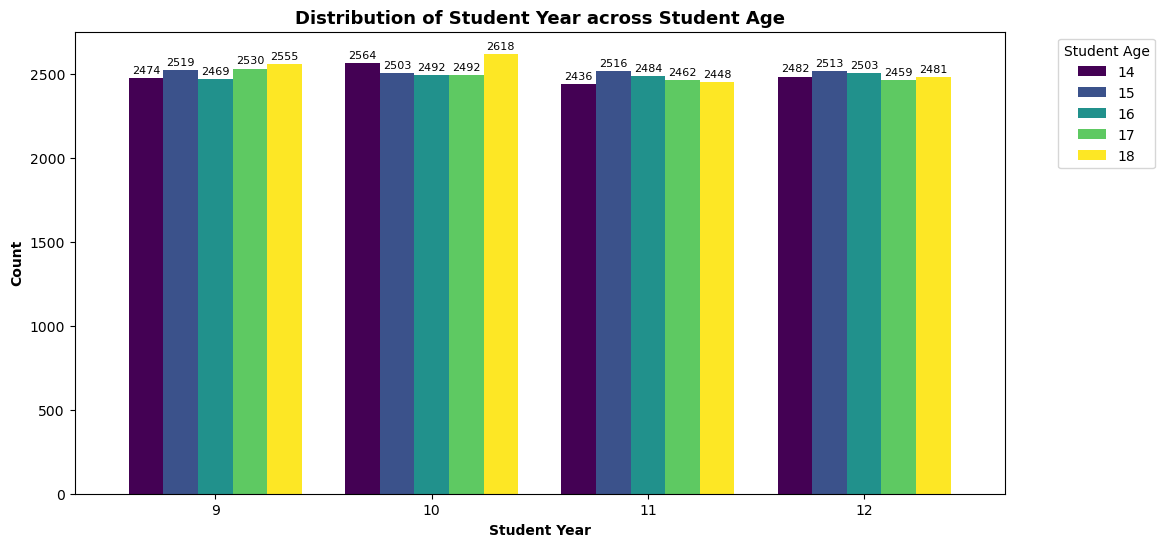

In [23]:
ax = year_age.plot(
    kind="bar",
    figsize=(12,6),
    width=0.8,
    colormap="viridis"
)

plt.title("Distribution of Student Year across Student Age", fontsize=13, fontweight='bold')
plt.xlabel("Student Year", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title="Student Age", bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)

plt.show()

/tmp/ipykernel_12280/4147780916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Student_Year", y="Average_Score", data=df, palette="coolwarm")


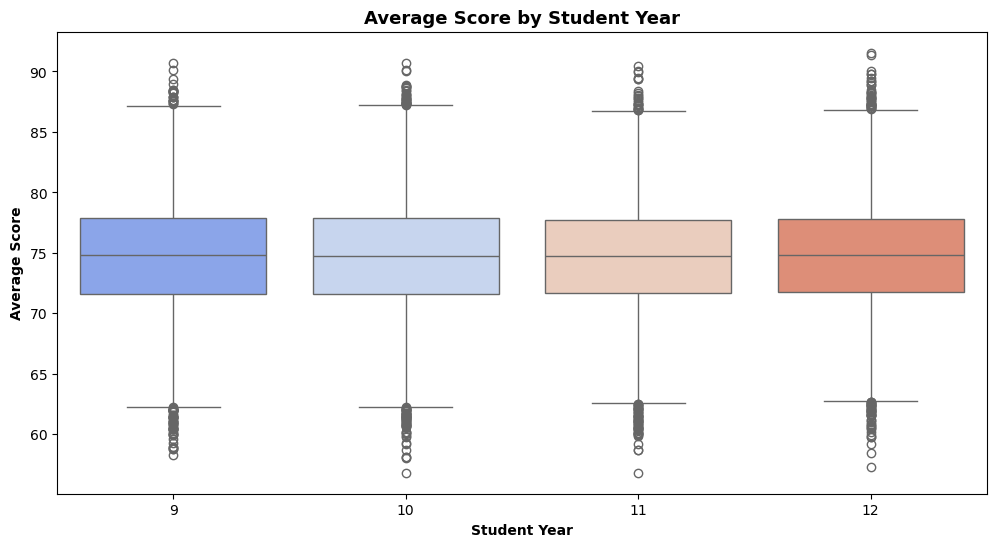

In [32]:
# Box plot: Student Year vs Average Score
plt.figure(figsize=(12,6))
sns.boxplot(x="Student_Year", y="Average_Score", data=df, palette="coolwarm")
plt.title("Average Score by Student Year", fontsize=13, fontweight='bold')
plt.xlabel("Student Year", fontsize=10, fontweight='bold')
plt.ylabel("Average Score", fontsize=10, fontweight='bold')
plt.show()

/tmp/ipykernel_12280/1715336956.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Student_Year_num", y="Total_Score", data=df, palette="husl")


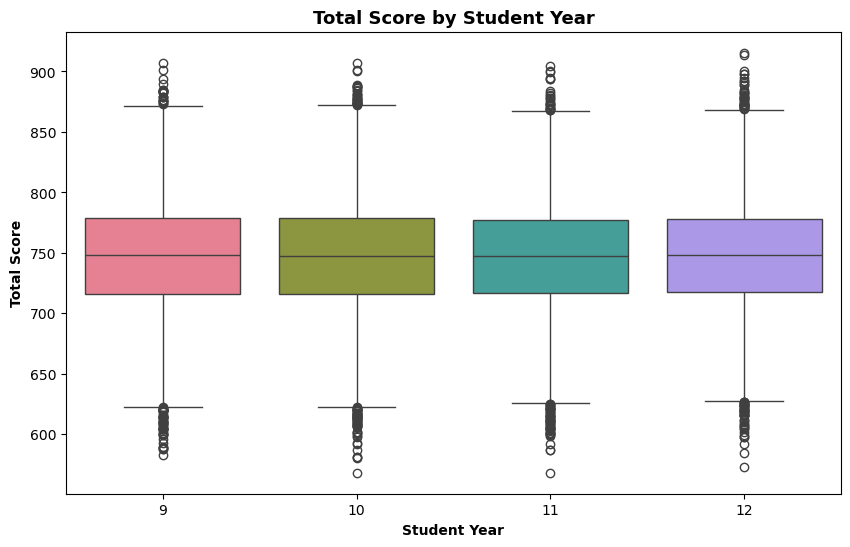

In [31]:
# Box plot: Student Year vs Total Score
plt.figure(figsize=(10,6))
sns.boxplot(x="Student_Year_num", y="Total_Score", data=df, palette="husl")
plt.title("Total Score by Student Year", fontsize=13, fontweight='bold')
plt.xlabel("Student Year", fontsize=10, fontweight='bold')
plt.ylabel("Total Score", fontsize=10, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

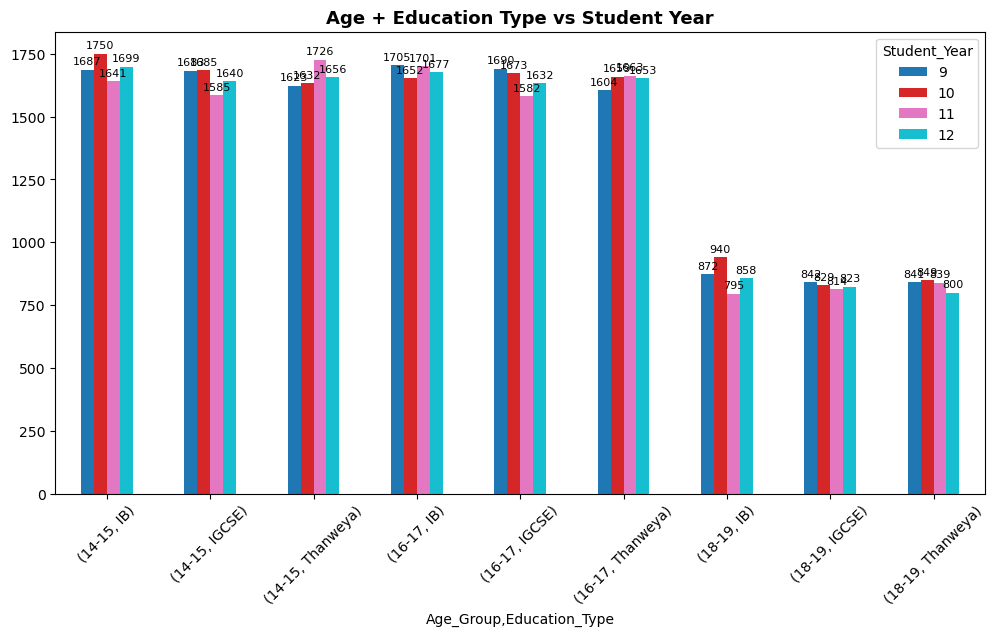

In [54]:
# Create Age Group column first
df["Age_Group"] = pd.cut(df["Student_Age"],
                         bins=[13,15,17,19],
                         labels=["14-15","16-17","18-19"])

counts = df.groupby(["Age_Group", "Education_Type", "Student_Year"]).size()
counts = counts.unstack(fill_value=0)

counts.plot(kind="bar", figsize=(12,6),
            color=[plt.cm.tab10(i / (len(counts.columns)-1)) for i in range(len(counts.columns))])

plt.title("Age + Education Type vs Student Year", fontsize=13, fontweight='bold')

plt.xticks(rotation=45)

for container in plt.gca().containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x() + bar.get_width()/2, h + 20, int(h),
                     ha='center', fontsize=8)

plt.show()

<Figure size 1200x600 with 0 Axes>

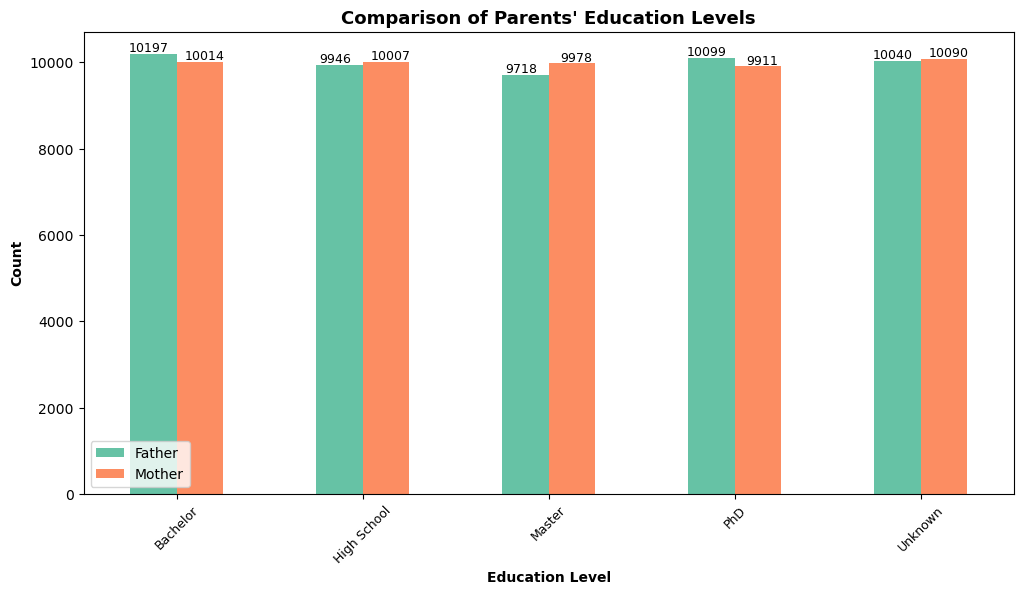

In [35]:
# Selecting the columns for parents' education
parents = ["Father_Degree", "Mother_Degree"]

# Counting occurrences for each degree
father_counts = df["Father_Degree"].value_counts().sort_index()
mother_counts = df["Mother_Degree"].value_counts().sort_index()

# Make sure both have the same index (fill missing with 0)
all_degrees = sorted(set(father_counts.index).union(set(mother_counts.index)))
father_counts = father_counts.reindex(all_degrees, fill_value=0)
mother_counts = mother_counts.reindex(all_degrees, fill_value=0)

# Creating a DataFrame for plotting
comparison = pd.DataFrame({
    "Father": father_counts,
    "Mother": mother_counts
})

# Plotting the comparison as a grouped bar chart
plt.figure(figsize=(12,6))
comparison.plot(kind="bar", figsize=(12,6), color=[plt.cm.Set2(i) for i in range(len(comparison.columns))])

# Adding titles and labels
plt.title("Comparison of Parents' Education Levels", fontsize=13, fontweight='bold')
plt.xlabel("Education Level", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')

# Customizing ticks
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=10)

# Adding value labels on top of bars
for i, (f, m) in enumerate(zip(father_counts, mother_counts)):
    plt.text(i-0.15, f + 50, str(f), ha='center', fontsize=9)   # Father label
    plt.text(i+0.15, m + 50, str(m), ha='center', fontsize=9)   # Mother label

plt.show()

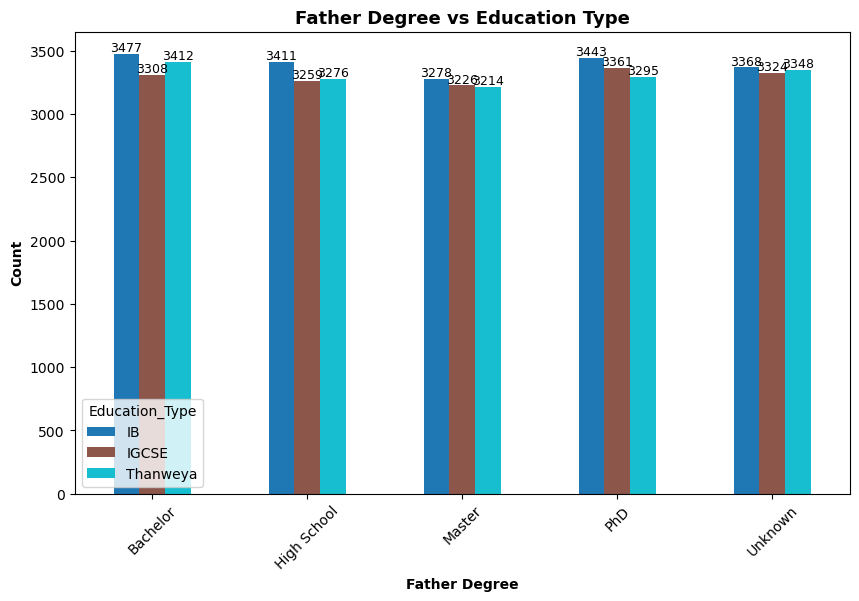

In [45]:
# Father Degree vs Education Type
counts = df.groupby(["Father_Degree", "Education_Type"]).size().unstack(fill_value=0)

counts.plot(kind="bar", figsize=(10,6),
            color=[plt.cm.tab10(i / (len(counts.columns)-1)) for i in range(len(counts.columns))])

plt.title("Father Degree vs Education Type", fontsize=13, fontweight='bold')
plt.xlabel("Father Degree", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

for container in plt.gca().containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x() + bar.get_width()/2, h + 20, int(h),
                     ha='center', fontsize=9)

plt.show()

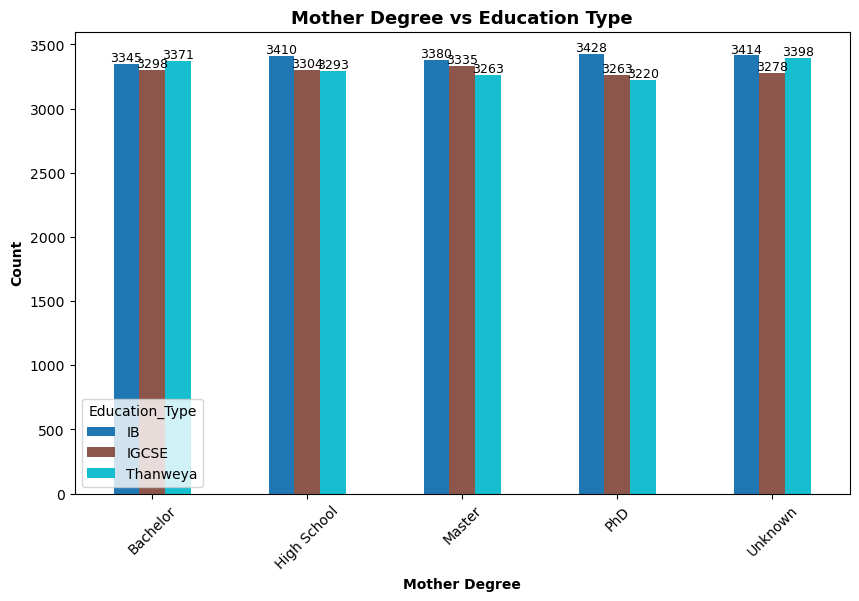

In [46]:
# Mother Degree vs Education Type
counts = df.groupby(["Mother_Degree", "Education_Type"]).size().unstack(fill_value=0)

counts.plot(kind="bar", figsize=(10,6),
            color=[plt.cm.tab10(i / (len(counts.columns)-1)) for i in range(len(counts.columns))])

plt.title("Mother Degree vs Education Type", fontsize=13, fontweight='bold')
plt.xlabel("Mother Degree", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

for container in plt.gca().containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x() + bar.get_width()/2, h + 20, int(h),
                     ha='center', fontsize=9)

plt.show()

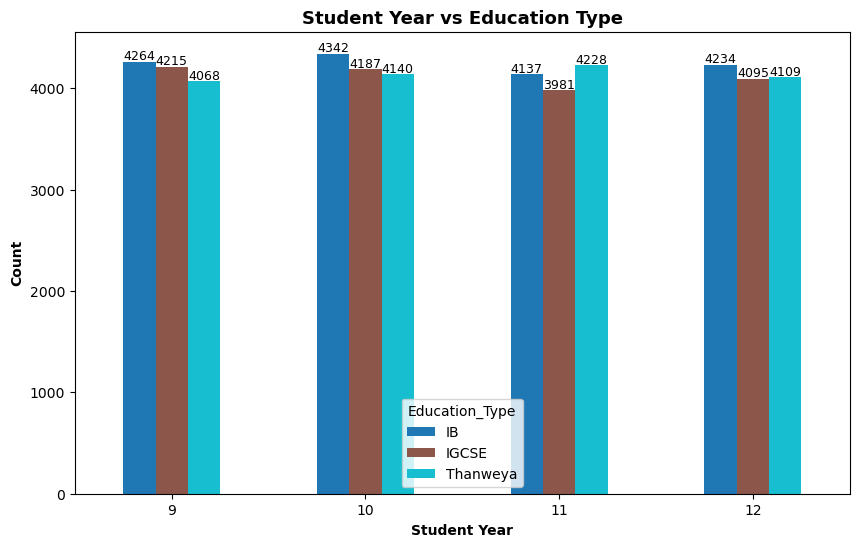

In [44]:
# Student Year vs Education Type
counts = df.groupby(["Student_Year", "Education_Type"]).size().unstack(fill_value=0)

counts.plot(kind="bar", figsize=(10,6),
            color=[plt.cm.tab10(i / (len(counts.columns)-1)) for i in range(len(counts.columns))])

plt.title("Student Year vs Education Type", fontsize=13, fontweight='bold')
plt.xlabel("Student Year", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

for container in plt.gca().containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x() + bar.get_width()/2, h + 20, int(h),
                     ha='center', fontsize=9)

plt.show()

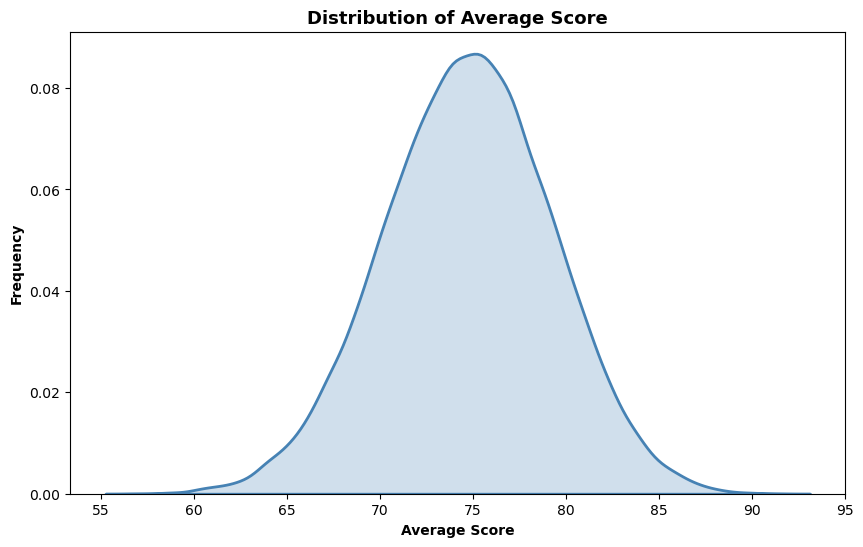

In [34]:
# Plotting the distribution of Average Score
plt.figure(figsize=(10,6))

sns.kdeplot(
    df["Average_Score"],
    fill=True,
    color="steelblue",
    linewidth=2
)

# Adding titles and labels
plt.title("Distribution of Average Score", fontsize=13, fontweight='bold')
plt.xlabel("Average Score", fontsize=10, fontweight='bold')
plt.ylabel("Frequency", fontsize=10, fontweight='bold')

# Customizing ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

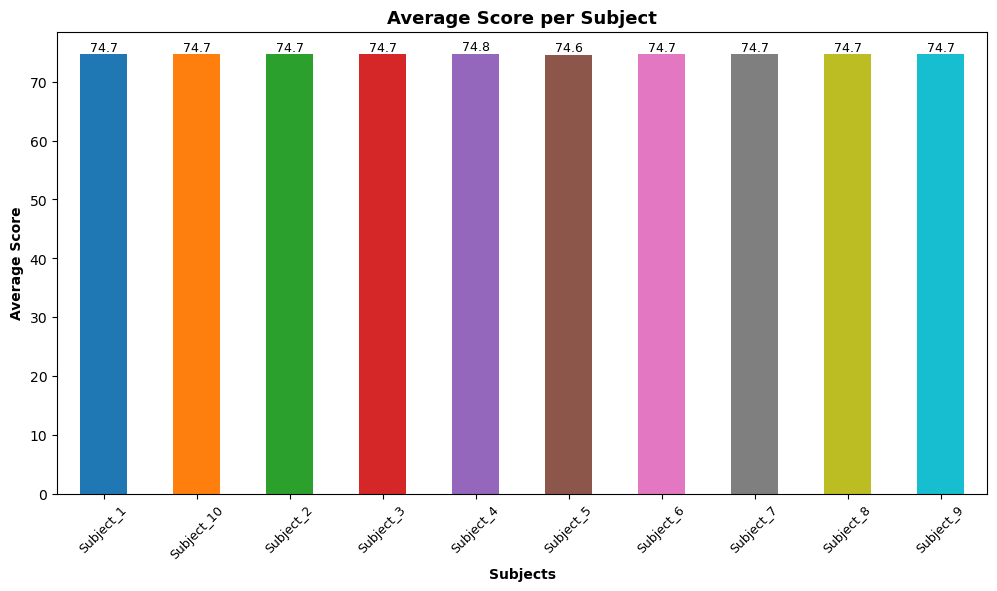

In [36]:
# Calculating average score per subject
subjects = [col for col in df.columns if "Subject" in col]

# Calculating average score per subject
means = df[subjects].mean().sort_index()
plt.figure(figsize=(12,6))
means.plot(kind="bar", color=[plt.cm.tab10(i / (len(means)-1) if len(means)>1 else 0) for i in range(len(means))])

# Adding titles and labels
plt.title("Average Score per Subject", fontsize=13, fontweight='bold')
plt.xlabel("Subjects", fontsize=10, fontweight='bold')
plt.ylabel("Average Score", fontsize=10, fontweight='bold')

# Customizing ticks
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=10)

# Adding value labels on top of bars
for i, v in enumerate(means):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontsize=9)

plt.show()